In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [109]:
df = pd.read_csv("flights.csv")
df.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    int64 
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.5+ KB


In [111]:
df.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [112]:
df.shape

(144, 3)

In [113]:
df.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

In [114]:
df.drop_duplicates(inplace=True)

In [115]:
df.shape

(144, 3)

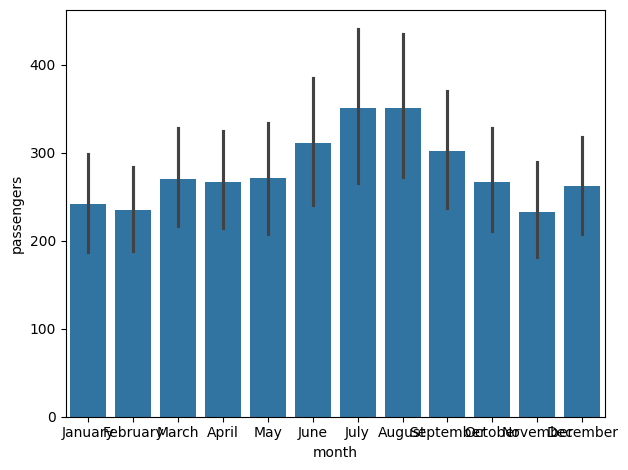

In [116]:
sns.barplot(x=df["month"],y=df["passengers"])
plt.tight_layout()
plt.show()

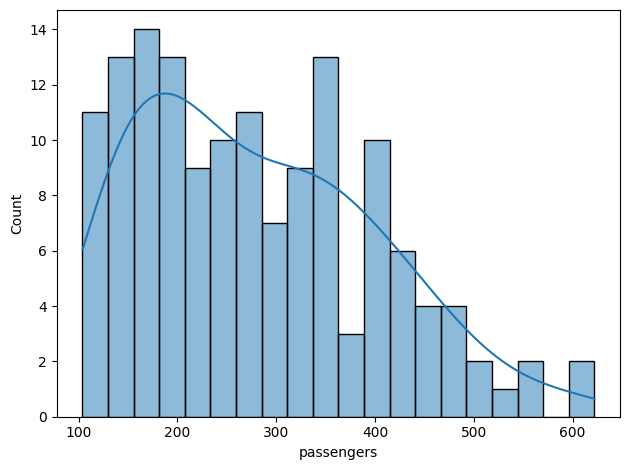

In [117]:
sns.histplot(df["passengers"],bins=20,kde=True)
plt.tight_layout()
plt.show()

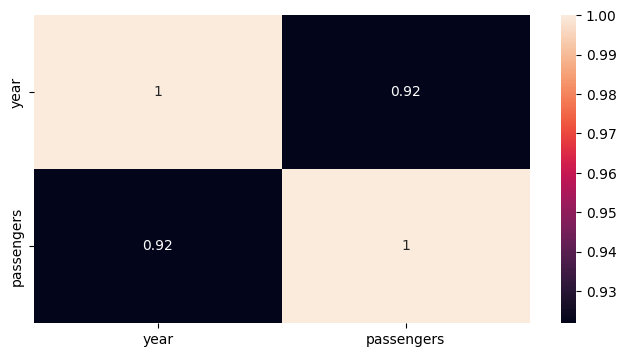

In [118]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

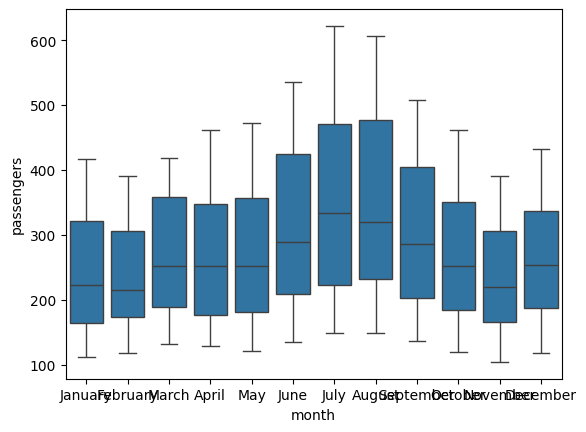

In [119]:
sns.boxplot(x=df["month"],y=df["passengers"])
plt.show()

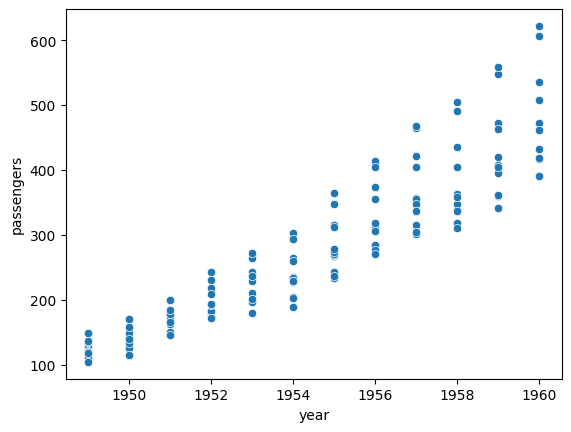

In [120]:
sns.scatterplot(x=df["year"],y=df["passengers"])
plt.show()

In [121]:
df.head()

,year,month,passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


In [122]:
df = pd.get_dummies(df,columns=["month"],drop_first=False)
df.head()

,year,passengers,month_April,month_August,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,1949,112,False,False,False,False,True,False,False,False,False,False,False,False
1,1949,118,False,False,False,True,False,False,False,False,False,False,False,False
2,1949,132,False,False,False,False,False,False,False,True,False,False,False,False
3,1949,129,True,False,False,False,False,False,False,False,False,False,False,False
4,1949,121,False,False,False,False,False,False,False,False,True,False,False,False


In [123]:
df.columns

Index(['year', 'passengers', 'month_April', 'month_August', 'month_December',
       'month_February', 'month_January', 'month_July', 'month_June',
       'month_March', 'month_May', 'month_November', 'month_October',
       'month_September'],
      dtype='object')

In [124]:
l = ['month_April', 'month_August', 'month_December',
       'month_February', 'month_January', 'month_July', 'month_June',
       'month_March', 'month_May', 'month_November', 'month_October',
       'month_September']

df[l] = df[l].astype(int)
df.head()

,year,passengers,month_April,month_August,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,1949,112,0,0,0,0,1,0,0,0,0,0,0,0
1,1949,118,0,0,0,1,0,0,0,0,0,0,0,0
2,1949,132,0,0,0,0,0,0,0,1,0,0,0,0
3,1949,129,1,0,0,0,0,0,0,0,0,0,0,0
4,1949,121,0,0,0,0,0,0,0,0,1,0,0,0


In [125]:
scaler = StandardScaler()
df[["year"]] = scaler.fit_transform(df[["year"]])
df.head()

,year,passengers,month_April,month_August,month_December,month_February,month_January,month_July,month_June,month_March,month_May,month_November,month_October,month_September
0,-1.593255,112,0,0,0,0,1,0,0,0,0,0,0,0
1,-1.593255,118,0,0,0,1,0,0,0,0,0,0,0,0
2,-1.593255,132,0,0,0,0,0,0,0,1,0,0,0,0
3,-1.593255,129,1,0,0,0,0,0,0,0,0,0,0,0
4,-1.593255,121,0,0,0,0,0,0,0,0,1,0,0,0


In [126]:
X = df.drop("passengers",axis=1)
y = df["passengers"]

In [127]:
X.columns

Index(['year', 'month_April', 'month_August', 'month_December',
       'month_February', 'month_January', 'month_July', 'month_June',
       'month_March', 'month_May', 'month_November', 'month_October',
       'month_September'],
      dtype='object')

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [129]:
models = {
    "LR":LinearRegression(),
    "KNN":KNeighborsRegressor(n_neighbors=5),
    "DT":DecisionTreeRegressor(max_depth=None,random_state=42),
    "RF":RandomForestRegressor(n_estimators=100,max_depth=None,random_state=42),
    "ADA":AdaBoostRegressor(n_estimators=100,random_state=42),
    "GD":GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,random_state=42),
    "XG":XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,use_label_encoder=False,eval_metric="mlogloss",random_state=42)
}
results = []

In [130]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    n = X_test.shape[0] 
    p = X_test.shape[1]
    r2 = r2_score(y_test,y_pred)
    r2_Ad = 1-((1-r2)*(n-1))/(n-p-1)    
    results.append([
        name,
        round(r2,2),
        round(r2_Ad,2)
    ])
results

c:\Users\Amir sohail\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:199: UserWarning: [06:41:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[['LR', 0.94, 0.88],
 ['KNN', 0.92, 0.86],
 ['DT', 0.89, 0.79],
 ['RF', 0.92, 0.85],
 ['ADA', 0.86, 0.74],
 ['GD', 0.98, 0.96],
 ['XG', 0.97, 0.95]]

In [131]:
models_df = pd.DataFrame(results,columns=["Models","R2_score","R2_AD_score"])
models_df

,Models,R2_score,R2_AD_score
0,LR,0.94,0.88
1,KNN,0.92,0.86
2,DT,0.89,0.79
3,RF,0.92,0.85
4,ADA,0.86,0.74
5,GD,0.98,0.96
6,XG,0.97,0.95


In [132]:
final_model = models["GD"]
final_model.fit(X_train,y_train)
y_pred = final_model.predict(X_test)
r2_score(y_test,y_pred)


0.976704609984365

In [133]:
from joblib import dump

dump(final_model,"model.pkl")
dump(scaler,"scaler.pkl")
dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']